# Определение возраста покупателей

## Описание проекта

Сетевой супермаркет «Хлеб-Соль» внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:
- анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;
- контролировать добросовестность кассиров при продаже алкоголя.

**Цель —** построить модель, которая по фотографии определит приблизительный возраст человека с MAE не больше 8.

В распоряжении набор фотографий людей с указанием возраста.

## Импорт библиотек, определение константы

In [6]:
# импортируем библиотеки
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [7]:
# вводим константу
RANDOM_STATE = 42

## Исследовательский анализ данных

In [8]:
# загружаем labels
labels = pd.read_csv('/datasets/faces/labels.csv')

In [9]:
# получаем общую информацию о датасете с целевым признаком
labels.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


In [10]:
# получаем первые записи
labels.head(3)

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80


Размер датасета `labels` 7591 записей, тип данных соответствует описанию, пропуски отсутствуют.

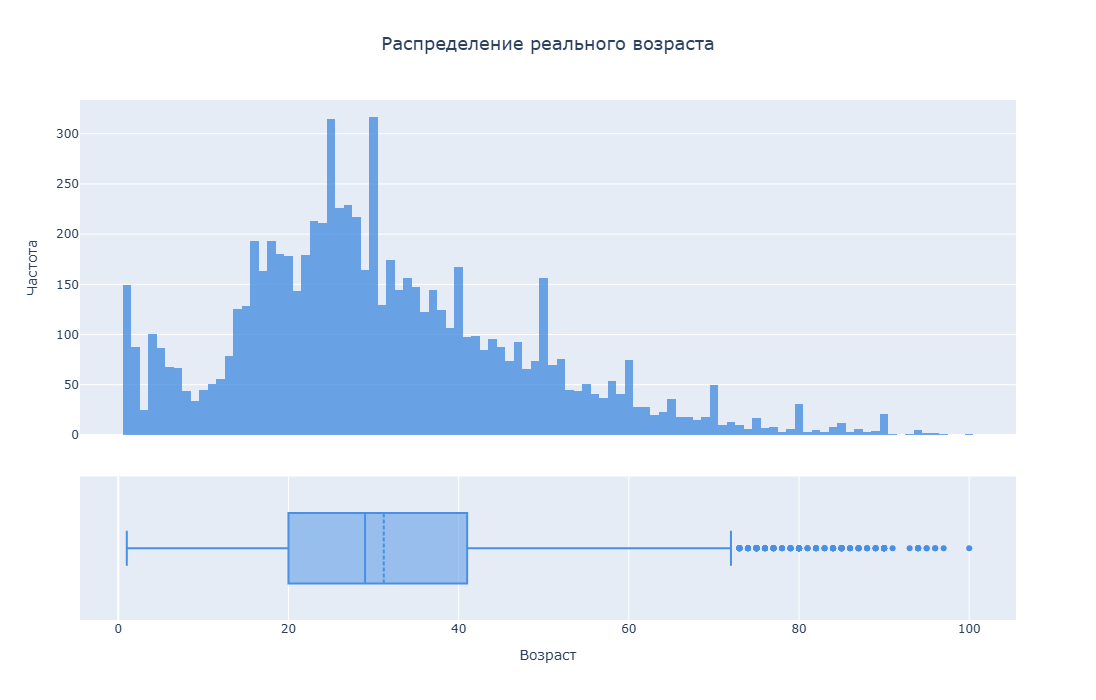

In [5]:
# построем распеределение по возрасту
age_data = labels['real_age']

# создаём подграфики: 2 строки, 1 столбец
fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    vertical_spacing=0.08,
    row_heights=[0.7, 0.3]
)

# гистограмма
fig.add_trace(
    go.Histogram(
        x=age_data,
        nbinsx=100,
        marker_color='#4A90E2',
        opacity=0.8,
        name='Гистограмма',
        histnorm=''  # абсолютные частоты
    ),
    row=1, col=1
)

# boxplot
fig.add_trace(
    go.Box(
        x=age_data,
        name='',
        marker_color='#4A90E2',
        boxmean=True
    ),
    row=2, col=1
)

# настройка внешнего вида
fig.update_layout(
    height=700,
    showlegend=False,
    title_text="Распределение реального возраста",
    title_x=0.5,
    title_font_size=18
)

fig.update_xaxes(title_text="Возраст", row=2, col=1)
fig.update_yaxes(title_text="Частота", row=1, col=1)

fig.show()

Мы наблюдаем не нормальное распределение по возрасту: есть два пика в области до 7 лет и в области 22-33. При этом медиана и среднее значения практически совпадают: 29 и 31. После максимума в области 22-33 наблюдаем плавный спад распределения вплоть до максимального значения 100 лет.

In [6]:
%%time
# извлекаем данные из папки
datagen = ImageDataGenerator(rescale=1./255) 

datagen_flow = datagen.flow_from_dataframe(
    dataframe=labels,
    # папка, в которой хранится датасет
    directory='/datasets/faces/final_files/',
    x_col='file_name',        # колонка с именами файлов
    y_col='real_age',         # колонка с возрастом
    # к какому размеру приводить изображения
    target_size=(150, 150), 
    # размер батча
    batch_size=16,
    class_mode='raw',
    seed=RANDOM_STATE
)

Found 7591 validated image filenames.
CPU times: user 579 ms, sys: 394 ms, total: 973 ms
Wall time: 1min 22s


Количество изображений соответствует размеру датасета.

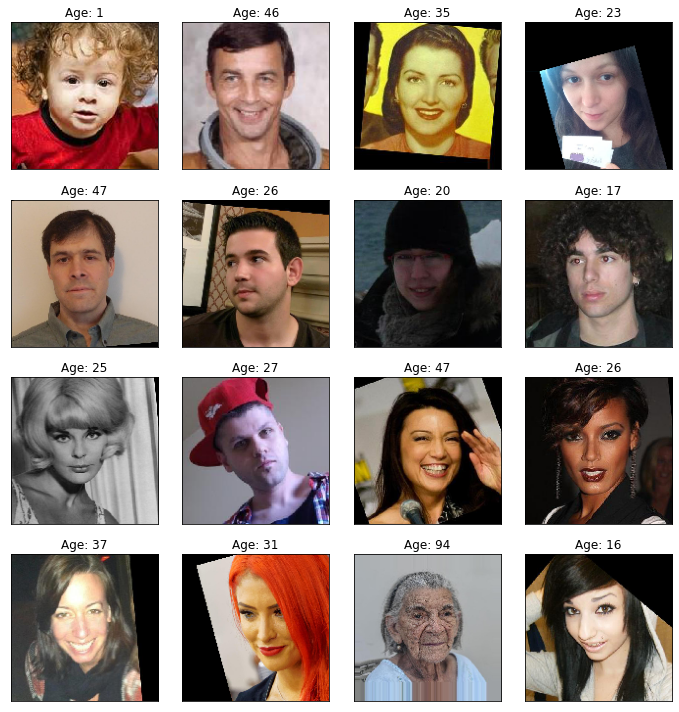

In [7]:
# напечатаем на экране 16 фотографий
features, ages = next(datagen_flow)

# выводим 16 изображений
fig = plt.figure(figsize=(10,10))
for i in range(16):
    fig.add_subplot(4, 4, i+1)
    plt.imshow(features[i])
    plt.title(f"Age: {ages[i]:.0f}")
    # для компактности удаляем оси и прижимаем изображения друг к другу
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()

В датасете представлены в основном фронтальные портреты лиц в хорошем качестве. Есть также портреты и под другими ракурсами. Преобладают взрослые в возрасте 20–40 лет, детей и пожилых людей заметно меньше. Люди разных национальностей. На некоторых изображениях присутствуют очки, шляпа, у людей могут быть усы, борода, их лица могут быть частично чем-то прикрыты, а также на фотографии могут быть видны части лиц других людей, но лица всегда чётко видны. Кроме этого к некоторым изображениям применяны фильтры: повороты, смещения. Большинство изображений цветные, но есть также и черно-белые. Возраст на первый взгляд соответствует людям на фотографиях.

**Промежуточные выводы по исследовательскому анализу**

1. Распределение по возрасту имеет два пика в области до 7 лет и в области 22-33. При этом медиана и среднее значения практически совпадают: 29 и 31. После максимума в области 22-33 наблюдается плавный спад распределения вплоть до максимального значения 100 лет.
2. Неравномерное распределение возраста с двумя пиками в обучающей выборке может привести к тому, что модель разные возрастные категории будет определять с разной точностью.
3. Фотографии людей разнообразны и охватывают разные национальности, разный возраст, различные ракурсы портретов, разные фильтры, разные сложности, например, части лиц могут быть чем-то прикрыты. В целом широкий спектр портретов благоприятным образом скажется на предсказательной способности модели. 

## Обучение модели

Перенесите сюда код обучения модели и её результат вывода на экран.


(Код в этом разделе запускается в отдельном GPU-тренажёре, поэтому оформлен не как ячейка с кодом, а как код в текстовой ячейке)

```python

# < скопируйте код сюда >
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import os
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.applications.resnet import ResNet50
from keras.applications.resnet50 import preprocess_input
from tensorflow.keras.optimizers import Adam

# задаем константы
RANDOM_STATE = 42
TEST_SIZE = 0.2

# загружаем labels
labels = pd.read_csv('/datasets/faces/labels.csv')

# Разделяем на train и test
train_labels, test_labels = train_test_split(
    labels,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)


def load_train(path):
    # извлекаем данные из папки
    train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)  # без rescale=1./255
    train_datagen_flow = train_datagen.flow_from_dataframe(
        dataframe=train_labels,
        # папка, в которой хранится датасет
        directory='/datasets/faces/final_files/',
        x_col='file_name',        # колонка с именами файлов
        y_col='real_age',         # колонка с возрастом
        # к какому размеру приводить изображения
        target_size=(224, 224),   # модель ResNEt обучалась на изображениях размером 224х224
        # размер батча
        batch_size=16,
        shuffle=True,
        class_mode='raw',
        seed=RANDOM_STATE
    )
    return train_datagen_flow


def load_test(path):
    # извлекаем данные из папки
    # И обучающие, и тестовые данные должны проходить одинаковую предобработку — т.е. оба через preprocess_input.
    # Иначе получим смещение (domain shift), и метрики на тесте будут некорректными
    test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)     
    test_datagen_flow = test_datagen.flow_from_dataframe(
        dataframe=test_labels,
        # папка, в которой хранится датасет
        directory='/datasets/faces/final_files/',
        x_col='file_name',        # колонка с именами файлов
        y_col='real_age',         # колонка с возрастом
        # к какому размеру приводить изображения
        target_size=(224, 224),   # модель ResNEt обучалась на изображениях размером 224х224
        # размер батча
        batch_size=16,
        shuffle=False,
        class_mode='raw',
        seed=RANDOM_STATE
    )
    return test_datagen_flow


def create_model(input_shape):
    backbone = ResNet50(input_shape=input_shape,
                    weights='/datasets/keras_models/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5', 
                    include_top=False
                       )
    
    optimizer = Adam(lr=0.0001)
    # замораживаем ResNet50 без верхушки
    #backbone.trainable = False
    
    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(128, activation='relu'))
    model.add(Dense(1, activation='linear'))
    model.compile(optimizer=optimizer, loss='mse',
                  metrics=['mae'])
    return model


def train_model(model, train_data, val_data, batch_size=None, epochs=5,
                steps_per_epoch=None, validation_steps=None):

    train_gen = train_data[0] if isinstance(train_data, tuple) else train_data
    val_gen = val_data[0] if isinstance(val_data, tuple) else val_data
    
    model.fit(
        train_gen,
        validation_data=val_gen,
        batch_size=batch_size, epochs=epochs,
        steps_per_epoch=steps_per_epoch,
        validation_steps=validation_steps,
        verbose=2
    )
    return model

```

```

# < скопируйте результат вывода на экран сюда >
# < длинные строки со скачиванием модели можно удалить >
<class 'tensorflow.python.keras.engine.sequential.Sequential'>
WARNING:tensorflow:sample_weight modes were coerced from
  ...
    to  
  ['...']
WARNING:tensorflow:sample_weight modes were coerced from
  ...
    to  
  ['...']
Train for 380 steps, validate for 95 steps
Epoch 1/5
2025-11-09 20:25:47.423313: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcublas.so.10
2025-11-09 20:25:47.862529: I tensorflow/stream_executor/platform/default/dso_loader.cc:44] Successfully opened dynamic library libcudnn.so.7
380/380 - 59s - loss: 179.1740 - mae: 9.8494 - val_loss: 106.6640 - val_mae: 7.7199
Epoch 2/5
380/380 - 58s - loss: 60.6776 - mae: 5.9524 - val_loss: 113.6274 - val_mae: 8.2034
Epoch 3/5
380/380 - 58s - loss: 31.7106 - mae: 4.3804 - val_loss: 98.2908 - val_mae: 7.4842
Epoch 4/5
380/380 - 48s - loss: 18.6731 - mae: 3.3040 - val_loss: 75.4223 - val_mae: 6.5560
Epoch 5/5
380/380 - 54s - loss: 14.3797 - mae: 2.8610 - val_loss: 77.1670 - val_mae: 6.6127
WARNING:tensorflow:sample_weight modes were coerced from
  ...
    to  
  ['...']
95/95 - 9s - loss: 77.1670 - mae: 6.6127
Test MAE: 6.6127

```

## Анализ обученной модели

Согласно исследовательскому анализу датасет имеет неравномерное распределение возраста с двумя пиками, что может привести к тому, что модель разные возрастные категории будет определять с разной точностью. При этом фотографии людей разнообразны и охватывают разные национальности, разный возраст, различные ракурсы портретов, разные фильтры, разные сложности, например, части лиц могут быть чем-то прикрыты. В целом широкий спектр портретов благоприятным образом скажется на предсказательной способности модели.

За основу взята модель `ResNet50`, верхние слои которой адаптированы под задачу регрессии. Данная модель позволила достичь цели проекта MAE не больше 8: на тестовой выборке MAE получается меньше 7.